In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import yfinance as yf
from datetime import time
sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

# Para ir tocando data_cleaner sin tener que reiniciar el kernel
%load_ext autoreload
%autoreload 2

# Configuración para datos a 5m
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol=["QQQ", "TLT", "VXX", "BNDX"],
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
   
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw, "qqq")

df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,datetime,open_bndx,open_qqq,open_tlt,open_vxx,high_bndx,high_qqq,high_tlt,high_vxx,low_bndx,...,log_return_lag5,vol_rolling,rsi,macd,macd_signal,ema_9,ema_21,ema_50,ema_100,ema_200
0,2022-01-03 14:25:00+00:00,55.060,399.38,146.550,18.2100,55.0600,399.4100,146.6000,18.30,55.0600,...,-0.000275,0.000512,21.777778,-0.000707,-0.000518,399.110000,399.110000,399.110000,399.110000,399.110000
1,2022-01-03 14:30:00+00:00,55.030,399.05,146.410,18.2700,55.0600,400.6800,146.5000,18.29,55.0100,...,0.000601,0.000921,50.991501,-0.000474,-0.000509,399.372000,399.229091,399.161373,399.135941,399.123035
2,2022-01-03 14:35:00+00:00,55.020,400.44,146.360,18.1200,55.0350,401.5300,146.5950,18.16,55.0100,...,-0.000025,0.000983,60.246913,-0.000158,-0.000439,399.709600,399.395537,399.235829,399.174041,399.142308
3,2022-01-03 14:40:00+00:00,55.030,401.07,146.570,18.0701,55.0400,401.2600,146.8000,18.15,55.0300,...,0.000326,0.001024,57.547170,-0.000008,-0.000353,399.879680,399.501397,399.287757,399.201486,399.156414
4,2022-01-03 14:45:00+00:00,55.030,400.57,146.530,18.1100,55.0500,400.7500,146.9400,18.56,55.0300,...,-0.000050,0.001669,36.489076,-0.000359,-0.000354,399.547244,399.384679,399.245786,399.182001,399.147072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79885,2025-12-31 20:40:00+00:00,48.330,615.36,87.325,26.5400,48.3399,615.5700,87.3300,26.55,48.3200,...,0.000292,0.000554,38.772455,-0.001009,-0.000907,615.561505,616.163054,616.961364,617.838238,618.927237
79886,2025-12-31 20:45:00+00:00,48.335,615.55,87.300,26.5200,48.3400,615.6261,87.3099,26.61,48.3201,...,-0.000666,0.000576,28.808833,-0.001033,-0.000932,615.441204,616.053685,616.882879,617.781244,618.887762
79887,2025-12-31 20:50:00+00:00,48.330,614.95,87.260,26.6200,48.3300,615.2700,87.2650,26.63,48.3200,...,-0.000455,0.000577,25.969742,-0.001047,-0.000955,615.334963,615.949714,616.805511,617.724387,618.848182
79888,2025-12-31 20:55:00+00:00,48.330,614.92,87.230,26.5650,48.3300,615.3350,87.2400,26.59,48.3100,...,0.000851,0.000593,22.512573,-0.001128,-0.000990,615.123971,615.797922,616.706471,617.656182,618.802728


In [238]:
df.columns

Index(['datetime', 'open_bndx', 'open_qqq', 'open_tlt', 'open_vxx',
       'high_bndx', 'high_qqq', 'high_tlt', 'high_vxx', 'low_bndx', 'low_qqq',
       'low_tlt', 'low_vxx', 'close_bndx', 'close_qqq', 'close_tlt',
       'close_vxx', 'volume_bndx', 'volume_qqq', 'volume_tlt', 'volume_vxx',
       'vwap_bndx', 'vwap_qqq', 'vwap_tlt', 'vwap_vxx', 'trade_count_bndx',
       'trade_count_qqq', 'trade_count_tlt', 'trade_count_vxx', 'open', 'high',
       'low', 'close', 'volume', 'vwap', 'trade_count', 'volume_norm',
       'trade_count_norm', 'return', 'log_return_close', 'log_return_norm',
       'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap',
       'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling',
       'rsi', 'macd', 'macd_signal', 'ema_9', 'ema_21', 'ema_50', 'ema_100',
       'ema_200'],
      dtype='object')

## **Importacion de la variable de volatilidad GARCH**



In [239]:
from pathlib import Path

# --- Ajusta paths por si estás en notebook ---
ROOT = Path(".").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Import robusto (según tengas el proyecto)
try:
    from GARCH import Garch11OOSBest
except Exception:
    from src.GARCH import Garch11OOSBest
    
    
# 1) Instanciar con los mismos params que tu script
m = Garch11OOSBest(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
    horizonte_horas=2,
    test_ratio=0.2,
    train_val_ratio=0.2,
    escala_returns=100.0,
    usar_horario_regular=True,
    usar_estacionalidad=True,
    season_smooth_half_window=5,
    fit_window_train_bars=16000,
    mean_mode="Zero",
    dist_mode="normal",
)

# 2) Pipeline interno (tal cual tu main)
m.cargar()
m.crear_target()
m.split()
m.ajustar_estacionalidad_train()
m.fit_train_fit()
m.filtrar_h_all()

# 3) Calcular sigma_2h para TODO el dataset (donde haya futuro suficiente)
df_g = m.df[["datetime"]].copy()
sig = np.full(len(df_g), np.nan, dtype=float)

# Nota: predecir_vol_futura_en_t devuelve None al final si no hay futuro.
for t in range(len(df_g)):
    out = m.predecir_vol_futura_en_t(t=t, devolver_path=False)
    if out is not None:
        sig[t] = out["sigma_2h"]

df_g["garch_vol_2h"] = sig
df_g = df_g.dropna(subset=["garch_vol_2h"]).reset_index(drop=True)

# 4) Guardar para reusar (evitas recomputar GARCH cada vez)
out_path = "garch_vol_2h_by_datetime.csv"
df_g.to_csv(out_path, index=False)

print("Saved:", out_path, "| rows:", len(df_g))
print("garch_vol_2h quantiles:", np.quantile(df_g["garch_vol_2h"].values, [0.01,0.05,0.1,0.5,0.9,0.95,0.99]))
print("head:\n", df_g.head(3).to_string(index=False))

convergence_flag: 0
opt_message: Optimization terminated successfully

=== Params GARCH(1,1) (TRAIN_FIT) ===
omega=448.085739 alpha=0.100947 beta=0.875036 alpha+beta=0.975983 mu=0.000000
Saved: garch_vol_2h_by_datetime.csv | rows: 79167
garch_vol_2h quantiles: [0.00059981 0.00064707 0.00068026 0.00092084 0.00155706 0.00186155
 0.0027477 ]
head:
                  datetime  garch_vol_2h
2022-01-03 14:30:00+00:00      0.001302
2022-01-03 14:35:00+00:00      0.001278
2022-01-03 14:40:00+00:00      0.001240


In [240]:
HORIZON = 24  # 24 velas de 5m = 2 horas

# ratios (usa los mismos que tu pipeline)
TEST_RATIO = 0.20
VAL_RATIO  = 0.20  # dentro del tramo train (para calibrar umbrales en train_only)

# hiperparámetros del target
VOL_LOW_Q = 0.30   # "poca vol" = p30 de TRAIN
K_SIGMA   = 0.60   # umbral de retorno en "sigmas" de GARCH

df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# -------------------------
# 1) MERGE GARCH vol 2h
# -------------------------
df_g = pd.read_csv("garch_vol_2h_by_datetime.csv")
df_g["datetime"] = pd.to_datetime(df_g["datetime"], utc=True, errors="coerce")
df_g = df_g.dropna(subset=["datetime"]).sort_values("datetime")

df = df.merge(df_g[["datetime", "garch_vol_2h"]], on="datetime", how="left")
df = df.dropna(subset=["garch_vol_2h"]).reset_index(drop=True)

# -------------------------
# 2) TARGET (sin cruzar día NY)
# -------------------------
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

df["fwd_logret_2h"] = np.log(df["close_future"] / df["close"])

# -------------------------
# 3) Umbrales SOLO con TRAIN
# -------------------------
n = len(df)
corte_test = int(n * (1 - TEST_RATIO))
corte_val  = int(corte_test * (1 - VAL_RATIO))
df_train_only = df.iloc[:corte_val].copy()

vol_low = float(df_train_only["garch_vol_2h"].quantile(VOL_LOW_Q))
thr_dyn = K_SIGMA * df["garch_vol_2h"].values

# clases: 0=DOWN, 1=FLAT, 2=UP
df["direction_2h"] = 1  # por defecto FLAT

# si vol baja => FLAT (lateral)
low_vol_mask = (df["garch_vol_2h"].values <= vol_low)

# si no vol baja, decide por umbral dinamico
hi_vol_mask = ~low_vol_mask
df.loc[hi_vol_mask & (df["fwd_logret_2h"].values >  thr_dyn), "direction_2h"] = 2
df.loc[hi_vol_mask & (df["fwd_logret_2h"].values < -thr_dyn), "direction_2h"] = 0
df["direction_2h"] = df["direction_2h"].astype(np.int8)

# Limpieza auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

print("vol_low (train p30) =", vol_low)
print("Frac low_vol =", float(low_vol_mask.mean()))
print("Class dist:", df["direction_2h"].value_counts(normalize=True).sort_index().to_dict())
print("Rows df:", len(df))


vol_low (train p30) = 0.0008276896398576
Frac low_vol = 0.35287998247919405
Class dist: {0: 0.2734523288071251, 1: 0.4217404000584027, 2: 0.3048072711344722}
Rows df: 54792


In [241]:
DOWN, FLAT, UP = 0, 1, 2

TEST_RATIO = 0.20
VAL_RATIO  = 0.20

n = len(df)
corte_test = int(n * (1 - TEST_RATIO))
corte_val  = int(corte_test * (1 - VAL_RATIO))
df_train_only = df.iloc[:corte_val].copy()

qs = [0.20, 0.25, 0.30, 0.35]
ks = [0.50, 0.60, 0.70, 0.80]

rows = []
vol = df["garch_vol_2h"].values
ret = df["fwd_logret_2h"].values

for q in qs:
    vol_low = float(df_train_only["garch_vol_2h"].quantile(q))
    low_vol_mask = (vol <= vol_low)

    for k in ks:
        thr = k * vol
        y = np.full(len(df), FLAT, dtype=np.int8)

        hi = ~low_vol_mask
        y[hi & (ret >  thr)] = UP
        y[hi & (ret < -thr)] = DOWN

        # dist global (rápido)
        p0 = float(np.mean(y == DOWN))
        p1 = float(np.mean(y == FLAT))
        p2 = float(np.mean(y == UP))
        nonflat = 1.0 - p1

        rows.append((q, k, vol_low, float(low_vol_mask.mean()), p0, p1, p2, nonflat))

res = pd.DataFrame(rows, columns=[
    "VOL_LOW_Q","K_SIGMA","vol_low","frac_low_vol","p_down","p_flat","p_up","nonflat"
])

# Filtro “razonable”: FLAT entre 0.33 y 0.48 y noflat >= 0.45 y clases laterales no ridículas
good = res[(res["p_flat"].between(0.33, 0.48)) & (res["nonflat"] >= 0.45)]
good = good.sort_values(["nonflat","p_flat"], ascending=[False, True])

print("TOP combos:")
print(good.head(12).to_string(index=False))

print("\nAll combos (si quieres verlos):")
print(res.sort_values(["p_flat"], ascending=True).to_string(index=False))


TOP combos:
 VOL_LOW_Q  K_SIGMA  vol_low  frac_low_vol   p_down   p_flat     p_up  nonflat
      0.20      0.6 0.000766      0.252811 0.312819 0.333425 0.353756 0.666575
      0.20      0.7 0.000766      0.252811 0.306870 0.346164 0.346967 0.653836
      0.20      0.8 0.000766      0.252811 0.300628 0.358994 0.340378 0.641006
      0.25      0.5 0.000797      0.303000 0.299259 0.365601 0.335140 0.634399
      0.25      0.6 0.000797      0.303000 0.293127 0.377847 0.329026 0.622153
      0.25      0.7 0.000797      0.303000 0.287578 0.389655 0.322766 0.610345
      0.25      0.8 0.000797      0.303000 0.281720 0.401518 0.316762 0.598482
      0.30      0.5 0.000828      0.352880 0.279201 0.410388 0.310410 0.589612
      0.30      0.6 0.000828      0.352880 0.273452 0.421740 0.304807 0.578260
      0.30      0.7 0.000828      0.352880 0.268452 0.432581 0.298967 0.567419
      0.30      0.8 0.000828      0.352880 0.263031 0.443441 0.293528 0.556559
      0.35      0.5 0.000859      0.4024

In [242]:
HORIZON = 24  # 24 velas de 5m = 2 horas
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# TARGET

## Aseguramos el horario de Nueva York
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date

# el close future no es mas que el precio futuro que se quiere predecir (Esta vez de  la columna date_ny, que indica el del horario de nueva york)
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)

# elimina las ultimas filas ya que no tenemos datos de ses futuro
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

# la variable direccion compara el precio futuro con el actual, si es mayor guarda 1, y si es menor o igual 0
thr = 0.005
df["fwd_logret_2h"] = df["close_future"] / df["close"]

df["direction_2h"] = (df["fwd_logret_2h"] > 1).astype(np.int8)


print("direction_2h" in df.columns)
print(df[["close", "direction_2h"]].head())
 

True
      close  direction_2h
0  400.4200             0
1  401.0600             0
2  400.5600             0
3  398.2175             1
4  397.3500             1


### __Hacemos una primera limpieza de features y creamos nuevas features__

In [243]:
# Creamos returns (QQQ, TLT, VXX, BNDX)

df["return_qqq"] = df["close_qqq"].pct_change()
df["return_tlt"] = df["close_tlt"].pct_change()
df["return_vxx"] = df["close_vxx"].pct_change()
df["return_bndx"] = df["close_bndx"].pct_change()

# Ahora comprobamos que los valores sean acordes

print(df[["return_qqq", "return", "return_tlt", "return_vxx", "return_bndx"]].head())

   return_qqq    return  return_tlt  return_vxx  return_bndx
0         NaN  0.003282         NaN         NaN          NaN
1    0.001598  0.001598    0.001401   -0.002759     0.000182
2   -0.001247 -0.001247   -0.000102    0.002767     0.000091
3   -0.005848 -0.005848    0.002115    0.020419     0.000273
4   -0.002178 -0.002178   -0.002901   -0.000270    -0.000454


#### __Feature Risk-on vs Risk-off__

Interpretación:
- Si es un positivo fuerte, el dinero sale de los bonos hacia el equity, ya que 'renta' invertir en renta variable y el interes que ofrecen los bonos baja.
- Si es negativo, el dinero del equity va hacia los bonos, suben los tipos de interes de los bonos y la gente se refugia en renta fija.

In [244]:
df["spread_equity_bond"] = df["return_qqq"] - df["return_tlt"]

print(df["spread_equity_bond"].head())

0         NaN
1    0.000198
2   -0.001144
3   -0.007963
4    0.000722
Name: spread_equity_bond, dtype: float64


#### __Feature Equity vs Volatility shock__

Interpretación:
- Si sube equity y baja VXX, el entorno de inversión es sano, el mercado no tiene miedo
- Si ambos suben, el mercado es frágil

In [245]:
df["spread_equity_vol"] = df["return_qqq"] - df["return_vxx"]

print(df["spread_equity_vol"].head())

0         NaN
1    0.004358
2   -0.004014
3   -0.026267
4   -0.001908
Name: spread_equity_vol, dtype: float64


#### __Volatility Shock puro__
Captura eventos inesperados

In [246]:
df["vol_shock"] = df["return_vxx"]


#### __Momentum relativo corto plazo__ 

In [247]:
df["momentum_3h"] = df["return_qqq"].rolling(3).sum()
df["momentum_6h"] = df["return_qqq"].rolling(6).sum()

print(df[["momentum_3h", "momentum_6h"]])

       momentum_3h  momentum_6h
0              NaN          NaN
1              NaN          NaN
2              NaN          NaN
3        -0.005496          NaN
4        -0.009273          NaN
...            ...          ...
30772    -0.001279    -0.000684
30773    -0.001255    -0.001255
30774    -0.000628    -0.002116
30775    -0.000717    -0.001996
30776    -0.000757    -0.002013

[30777 rows x 2 columns]


#### __Ratio equity bond__
Cáptura régimen estructural

In [248]:
df["ratio_equity_bond"] = df["close_qqq"] / df["close_tlt"]

print(df["ratio_equity_bond"])

0        2.735857
1        2.736397
2        2.733265
3        2.711545
4        2.713509
           ...   
30772    7.057456
30773    7.052488
30774    7.050270
30775    7.051605
30776    7.051154
Name: ratio_equity_bond, Length: 30777, dtype: float64


#### __Divergencia intrahora (Spread)__
Captura expansión de rango

In [249]:
df["range_qqq"] = (df["high_qqq"] - df["low_qqq"]) / df["close_qqq"]

print(df["range_qqq"].head())

0    0.004196
1    0.003541
2    0.002621
3    0.007333
4    0.003372
Name: range_qqq, dtype: float64


#### __Intensidad del volumen__
Captura outliers y la participación anormal

In [250]:
df["volume_zscore"] = (
    df["volume_qqq"] - df["volume_qqq"].rolling(20).mean()
) / df["volume_qqq"].rolling(20).std()

print(df["volume_zscore"])

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
30772   -0.500187
30773   -1.008999
30774   -0.700566
30775   -0.506029
30776   -0.528141
Name: volume_zscore, Length: 30777, dtype: float64


In [251]:
FEATURE_COLUMNS = df.select_dtypes(include=["int64","int32","float64","float32","int8","int16","float16"]).columns.tolist()

unuseful_features = [
    "fwd_logret_2h", "close_future", 
    "volume_tlt", "volume_bndx", "volume_qqq", "volume_vxx",
    "vwap_tlt", "vwap_bndx", "vwap_qqq", "vwap_vxx",
    "trade_count_tlt", "trade_count_bndx", "trade_count_qqq", "trade_count_vxx",
]

FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if not c in unuseful_features]

# quitar las que no existan (por si Alpaca/YF no trae alguna)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in df.columns]

# Limpieza de columnas auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

# Eliminamos la variable target de FEATURE_COLUMNS
FEATURE_COLUMNS.remove("direction_2h")

df = df.dropna().reset_index(drop=True)

print("N features:", len(FEATURE_COLUMNS))
print("FEATURE_COLUMNS:", FEATURE_COLUMNS)
print("Rows df:", len(df))


N features: 58
FEATURE_COLUMNS: ['open_bndx', 'open_qqq', 'open_tlt', 'open_vxx', 'high_bndx', 'high_qqq', 'high_tlt', 'high_vxx', 'low_bndx', 'low_qqq', 'low_tlt', 'low_vxx', 'close_bndx', 'close_qqq', 'close_tlt', 'close_vxx', 'open', 'high', 'low', 'close', 'volume', 'vwap', 'trade_count', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'ema_9', 'ema_21', 'ema_50', 'ema_100', 'ema_200', 'garch_vol_2h', 'return_qqq', 'return_tlt', 'return_vxx', 'return_bndx', 'spread_equity_bond', 'spread_equity_vol', 'vol_shock', 'momentum_3h', 'momentum_6h', 'ratio_equity_bond', 'range_qqq', 'volume_zscore']
Rows df: 30758


#### __Eliminamos todas las features de open, close, high y low__

In [252]:
prefixes_to_remove = ("open", "close", "high", "low")

removed_cols = [
    col for col in FEATURE_COLUMNS
    if col.startswith(prefixes_to_remove)
]

FEATURE_COLUMNS = [
    col for col in FEATURE_COLUMNS
    if not col.startswith(prefixes_to_remove)
]

X = df[FEATURE_COLUMNS]
y = df["direction_2h"]

print("Columnas eliminadas:", removed_cols)
print("Total eliminadas:", len(removed_cols))


Columnas eliminadas: ['open_bndx', 'open_qqq', 'open_tlt', 'open_vxx', 'high_bndx', 'high_qqq', 'high_tlt', 'high_vxx', 'low_bndx', 'low_qqq', 'low_tlt', 'low_vxx', 'close_bndx', 'close_qqq', 'close_tlt', 'close_vxx', 'open', 'high', 'low', 'close']
Total eliminadas: 20


### Matriz de Correlacion

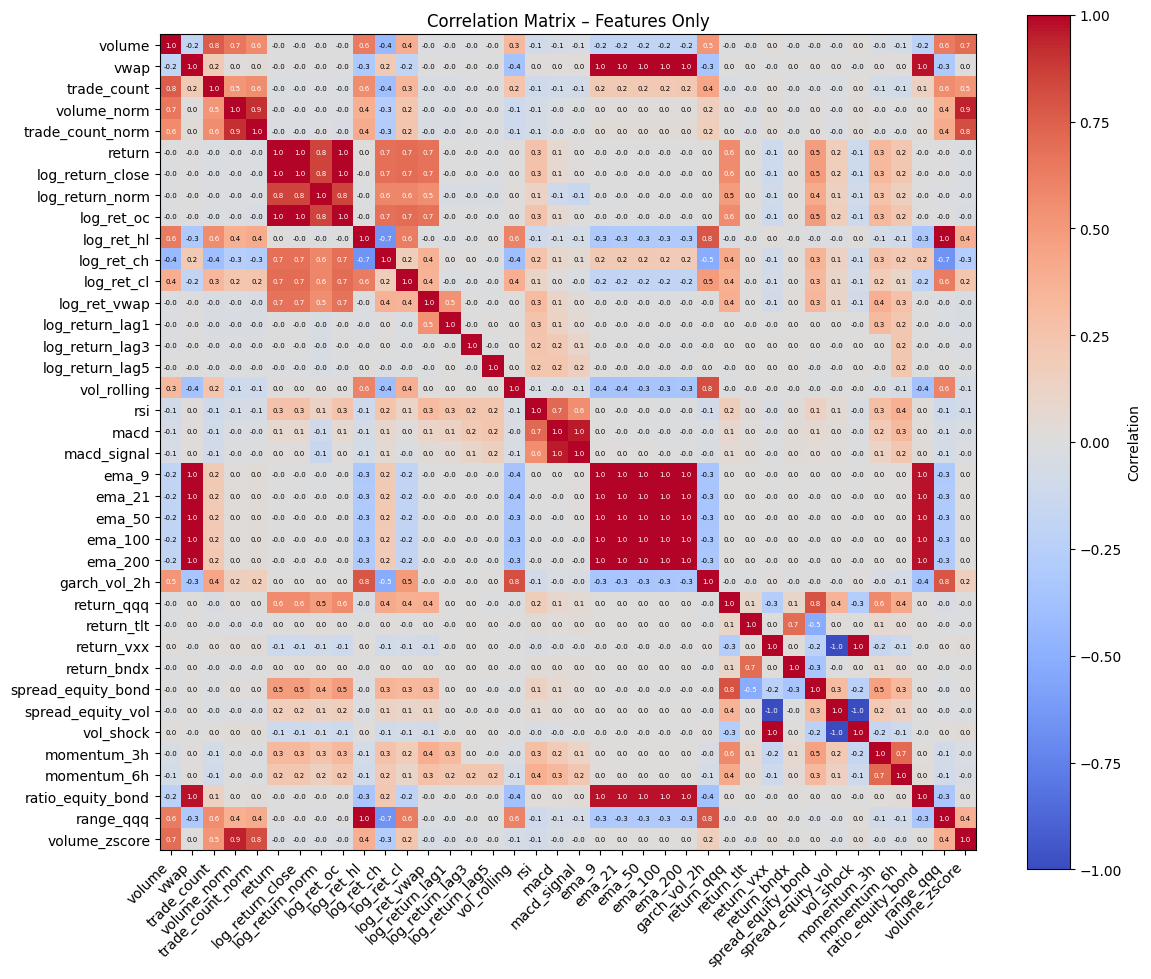

In [253]:
corr_features = X.corr()


plt.figure(figsize=(12, 10))
plt.imshow(corr_features, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_features.columns)), corr_features.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_features.index)), corr_features.index)

# Añadir valores dentro de cada celda
for i in range(len(corr_features)):
    for j in range(len(corr_features.columns)):
        value = corr_features.iloc[i, j]
        color = "white" if abs(value) > 0.5 else "black"
        plt.text(j, i, f"{value:.1f}",   # solo 1 decimal
                 ha="center", va="center",
                 fontsize=5,            # tamaño más pequeño
                 color=color)



plt.title("Correlation Matrix – Features Only")
plt.tight_layout()
plt.show()


In [254]:
# Calcular correlaciones originales
corr_target = X.corrwith(df["direction_2h"])

# Guardar variables con correlación negativa
negatively_correlated = corr_target[corr_target < 0].index.tolist()

# Convertir todas las correlaciones a valor absoluto
corr_target_abs = corr_target.abs()

# Ordenar de mayor a menor
corr_target_abs = corr_target_abs.sort_values(ascending=False)

# Mostrar correlaciones absolutas
print(corr_target_abs)

# Imprimir lista de variables que tenían correlación negativa
print("\nVariables con correlación negativa original:")
print(negatively_correlated)


macd                  0.057062
rsi                   0.055673
macd_signal           0.052670
garch_vol_2h          0.029819
momentum_6h           0.021001
ratio_equity_bond     0.020847
range_qqq             0.019032
log_ret_hl            0.019027
log_ret_ch            0.018830
log_return_lag5       0.018623
vol_rolling           0.017303
log_return_lag3       0.014471
trade_count           0.014011
momentum_3h           0.011003
volume                0.010987
vwap                  0.010498
ema_9                 0.010251
ema_21                0.009875
trade_count_norm      0.009812
ema_50                0.009371
log_ret_vwap          0.009055
ema_100               0.008973
log_return_lag1       0.008792
log_ret_oc            0.008669
log_return_close      0.008654
return                0.008603
ema_200               0.008454
spread_equity_vol     0.007809
return_vxx            0.007463
vol_shock             0.007463
volume_norm           0.006206
volume_zscore         0.006101
return_q

### __Eliminar Multicolinealidad extrema__ 
Eliminamos aquellas variables muy correlacionadas entre si y nos quedamos con una solo

In [255]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Solo eliminamos aquellas que tengan entre si una correlacion mayor de 0.9
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X_filtered = X.drop(columns=to_drop)

print(X_filtered.columns)
print(len(X_filtered.columns))


Index(['volume', 'vwap', 'trade_count', 'volume_norm', 'return',
       'log_return_norm', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl',
       'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5',
       'vol_rolling', 'rsi', 'macd', 'garch_vol_2h', 'return_qqq',
       'return_tlt', 'return_vxx', 'return_bndx', 'spread_equity_bond',
       'momentum_3h', 'momentum_6h'],
      dtype='object')
24


### __Filtrar por correlacion mínima con target__
Filtramos aquellas variables que tengan algo de correlación con el target. Aquellas que tengan muy poca serán descartadas de la lista de posibles features.

In [256]:
corr_target = X_filtered.corrwith(y).abs()

X_filtered = X_filtered.loc[:, corr_target > 0.01]

print(X_filtered.columns)
print(len(X_filtered.columns))

Index(['volume', 'vwap', 'trade_count', 'log_ret_hl', 'log_ret_ch',
       'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd',
       'garch_vol_2h', 'momentum_3h', 'momentum_6h'],
      dtype='object')
13


In [257]:
from sklearn.linear_model import LogisticRegression
from feature_selector import SequentialFeatureSelectorWrapper

model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelectorWrapper(
    model=model,
    n_features_to_select=8,
    direction="forward",
    cv=5
)

sfs.fit(X_filtered, y)

print("Features seleccionadas:")
print(sfs.get_selected_features())

print("ROC AUC medio:")
print(sfs.get_cv_score())


Features seleccionadas:
['trade_count', 'log_ret_ch', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'garch_vol_2h']
ROC AUC medio:
0.5325259640401384


In [258]:
# Define fechas clave para el test/val/train
VAL_START  = pd.Timestamp("2024-09-01", tz="UTC")
TEST_START = pd.Timestamp("2025-01-01", tz="UTC")
TEST_END   = pd.Timestamp("2026-01-01", tz="UTC")  # exclusivo

embargo = pd.Timedelta(hours=2)  # = horizonte (2h)

# Marca los limites del dataframe de train y de val
TRAIN_END = VAL_START - embargo
VAL_END   = TEST_START - embargo

# Creamos los dataframes de train/val/test
# val es el test real y test es el backtest que se usa para ver si la estrategia es viable a lo largo del tiempo
df_train = df[df["datetime"] < TRAIN_END].copy()
df_val   = df[(df["datetime"] >= VAL_START) & (df["datetime"] < VAL_END)].copy()
df_test  = df[(df["datetime"] >= TEST_START) & (df["datetime"] < TEST_END)].copy()

print("train:", df_train["datetime"].min(), "->", df_train["datetime"].max(), "| rows:", len(df_train))
print("val:  ", df_val["datetime"].min(),   "->", df_val["datetime"].max(),   "| rows:", len(df_val))
print("test: ", df_test["datetime"].min(),  "->", df_test["datetime"].max(),  "| rows:", len(df_test))

print("P(y=1) train:", df_train["direction_2h"].mean())
print("P(y=1) val:  ", df_val["direction_2h"].mean())
print("P(y=1) test: ", df_test["direction_2h"].mean())

train: 2022-01-03 16:05:00+00:00 -> 2024-08-30 16:00:00+00:00 | rows: 20592
val:   2024-09-03 13:30:00+00:00 -> 2024-12-31 17:00:00+00:00 | rows: 2542
test:  2025-01-02 14:30:00+00:00 -> 2025-12-30 17:00:00+00:00 | rows: 7624
P(y=1) train: 0.5282148407148407
P(y=1) val:   0.533831628638867
P(y=1) test:  0.5457764952780693


### Sanity Check: clase target alineada en el tiempo
Realizaremos un Snaity Check para ver si la clase direction_2h esta alineada o no en el tiempo

In [259]:
# Sanity Check para variable direction_2h

idx = 1000

print(len(df))
print(df.index[:5])
print(df.index[-5:])
print(1000 in df.index)


df.loc[idx, ["datetime", "close", "direction_2h"]]

print(FEATURE_COLUMNS)



30758
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=30753, stop=30758, step=1)
True
['volume', 'vwap', 'trade_count', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'ema_9', 'ema_21', 'ema_50', 'ema_100', 'ema_200', 'garch_vol_2h', 'return_qqq', 'return_tlt', 'return_vxx', 'return_bndx', 'spread_equity_bond', 'spread_equity_vol', 'vol_shock', 'momentum_3h', 'momentum_6h', 'ratio_equity_bond', 'range_qqq', 'volume_zscore']


In [260]:
from sklearn.preprocessing import StandardScaler

# ---------- scaler para LSTM (solo FEATURE_COLUMNS) ----------
scaler_feats = StandardScaler()

X_train_raw = df_train[FEATURE_COLUMNS].values
X_val_raw   = df_val[FEATURE_COLUMNS].values
X_test_raw  = df_test[FEATURE_COLUMNS].values

X_train_scaled = scaler_feats.fit_transform(X_train_raw)
X_val_scaled   = scaler_feats.transform(X_val_raw)
X_test_scaled  = scaler_feats.transform(X_test_raw)

df_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
df_train_scaled["datetime"] = df_train["datetime"].values
df_train_scaled["direction_2h"] = df_train["direction_2h"].values

df_val_scaled = pd.DataFrame(X_val_scaled, columns=FEATURE_COLUMNS)
df_val_scaled["datetime"] = df_val["datetime"].values
df_val_scaled["direction_2h"] = df_val["direction_2h"].values

df_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)
df_test_scaled["datetime"] = df_test["datetime"].values
df_test_scaled["direction_2h"] = df_test["direction_2h"].values

### Sanity Check: Escalado de datasets
Antes de terminar con el escalado de los datos, comprobamos que ninguno de los datos, ni de train, val ni test sean nulos o tiendan a infinito.

In [261]:
def check_df(df, name, feature_cols):
    print(f"\n{name}")

    # Check global
    has_nan = df.isna().any().any()
    has_inf = np.isinf(df[feature_cols].values).any() if len(feature_cols) > 0 else False
    print(f"Global -> NaN: {has_nan} | INF: {has_inf}")

    # Columnas que queremos mirar si existen
    wanted = list(feature_cols) + ["direction_2h", "datetime"]
    cols_present = [c for c in wanted if c in df.columns]
    cols_missing = [c for c in wanted if c not in df.columns]

    if cols_missing:
        print("Missing columns (skip):", cols_missing)

    # NaNs por columna (solo presentes)
    nan_counts = df[cols_present].isna().sum()

    if nan_counts.sum() == 0:
        print("NaNs por columna: OK (0 en todas)")
    else:
        print("NaNs por columna:")
        print(nan_counts[nan_counts > 0])

        

check_df(df_train_scaled, "TRAIN", FEATURE_COLUMNS)
check_df(df_val_scaled,   "VAL",   FEATURE_COLUMNS)
check_df(df_test_scaled,  "TEST",  FEATURE_COLUMNS)




TRAIN
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

VAL
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

TEST
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)


### Sliding Window

In [262]:
"""Sliding Window con stride (menor correlación y ejemplos más independientes)"""
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDatasetStride(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128, stride=4):
        """
        df: dataframe escalado con columnas features + datetime + target
        seq_len: cuántas filas pasadas ve el modelo
        stride: cada cuántas filas se crea una nueva ventana
        """
        self.seq_len = seq_len
        self.stride = stride
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets  = torch.tensor(df[target_col].values, dtype=torch.long)
        
        # Guardamos timestamps
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        # Número de ventanas teniendo en cuenta el stride
        return max(0, (len(self.features) - self.seq_len) // self.stride + 1)

    def __getitem__(self, i):
        # Índice real teniendo en cuenta el stride
        idx = i * self.stride
        
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target asociado al último timestep de la ventana
        y = self.targets[idx + self.seq_len - 1]

        # Timestamp del momento de la predicción
        ts = self.timestamps[idx + self.seq_len - 1].astype(np.int64)

        return x, y, ts

In [263]:
SEQ_LEN = 64  # ventana de observación (64 velas)
STRIDE = 4 # saltos entre ventana y ventana

# Usamos la clase anterior para definir los datos de entrenamiento, de validations y de back-test
train_dataset = SlidingWindowDatasetStride(
    df_train_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

val_dataset = SlidingWindowDatasetStride(
    df_val_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

test_dataset = SlidingWindowDatasetStride(
    df_test_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

print(len(train_dataset), len(val_dataset), len(test_dataset))
# Comprobación rápida para estar seguros
print(len(df_train_scaled))
print(len(train_dataset))
# SI len(train_dataset) ≈ (len(df_train_scaled) - SEQ_LEN) // STRIDE + 1 todo Bien
print((len(df_train_scaled) - SEQ_LEN) // STRIDE + 1)



5133 620 1891
20592
5133
5133


In [264]:
# Definimos el BATCH SIZE y cargamos los datos para que sean entrenados
# Usamos shuffle=True en train_loader porque estamos usando STRIDE. Si no podría ser False dependiendo del caso
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [265]:
# Ver un batch
xb, yb, tsb = next(iter(train_loader))

print("Batch X:", xb.shape)   # (batch, seq_len, num_features)
print("Batch y:", yb.shape)   # (batch,)
print("Timestamp example:", tsb[0])

Batch X: torch.Size([64, 64, 38])
Batch y: torch.Size([64])
Timestamp example: tensor(1722519300000000000)


In [266]:
def loader_class_stats(loader, name=""):
    y = torch.cat([yb for _, yb, _ in loader]).cpu().numpy().astype(int)
    vals, cnts = np.unique(y, return_counts=True)
    total = cnts.sum()
    print(f"\n[{name}] N={total}")
    for v, c in zip(vals, cnts):
        print(f"  class {v}: {c} ({c/total:.3f})")
    return y

y_tr = loader_class_stats(train_loader, "TRAIN windows")
y_va = loader_class_stats(val_loader,   "VAL windows")



[TRAIN windows] N=5133
  class 0: 2415 (0.470)
  class 1: 2718 (0.530)

[VAL windows] N=620
  class 0: 286 (0.461)
  class 1: 334 (0.539)


## Ahora la LSTM

In [267]:
import torch.nn as nn

class LockedDropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p      # probabilidad de apagar una neurona 

    def forward(self, x):
        # x: (B, T, F)
        # En este primer caso no se aplica dropout
        if (not self.training) or self.p == 0.0:
            return x
        # misma máscara para todos los timesteps (deciden que features tendrán menor peso en función de p)
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - self.p)
        mask = mask / (1 - self.p)
        return x * mask


In [268]:
import torch.nn as nn

class LSTMClassifier_VDROP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.1, lstm_dropout=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=(lstm_dropout if num_layers > 1 else 0.0),
            batch_first=True
        )

        # Capa donde normalizamos las filas
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)          # (B, T, H)
        feat = out.mean(dim=1)         # pooling temporal (B, H)
        feat = self.norm(feat)
        logits = self.fc(feat)
        return logits

In [269]:
input_dim = len(FEATURE_COLUMNS)

model = LSTMClassifier_VDROP(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    vdrop_in=0.1
)

xb, yb, _ = next(iter(train_loader))
print("xb features:", xb.shape[-1], "input_dim:", input_dim)

xb features: 38 input_dim: 38


#### Checks rapidos antes de entrenar

In [270]:
print(np.unique(y_tr))

print("Batch y distribution:", torch.unique(yb, return_counts=True))


[0 1]
Batch y distribution: (tensor([0, 1]), tensor([29, 35]))


### __Entrenamiento modelo__

In [271]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#POR SI ACASO HICIESE FALTA BALANCEAR
counts = np.bincount(y_tr, minlength=2).astype(np.float32)
print("Counts:", counts)

class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum()

class_w = torch.tensor(class_weights, device=device, dtype=torch.float32)

print("Class weights:", class_w)

criterion = torch.nn.CrossEntropyLoss(weight=class_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
model

Counts: [2415. 2718.]
Class weights: tensor([0.5295, 0.4705])


LSTMClassifier_VDROP(
  (vdrop_in): LockedDropout()
  (lstm): LSTM(38, 64, num_layers=2, batch_first=True, dropout=0.2)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

In [272]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for xb, yb, _ in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 56.7324
Epoch 2, Loss: 56.0286
Epoch 3, Loss: 56.0890
Epoch 4, Loss: 55.6969
Epoch 5, Loss: 55.8172
Epoch 6, Loss: 55.3609
Epoch 7, Loss: 55.1487
Epoch 8, Loss: 54.9104
Epoch 9, Loss: 54.2864
Epoch 10, Loss: 54.0263


### __Evaluación del modelo__

In [273]:
import torch
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

def evaluate_lstm(model, loader, device="cpu"):
    
    model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            
            all_logits.append(logits.cpu())
            all_targets.append(yb.cpu())

    logits = torch.cat(all_logits)
    y_true = torch.cat(all_targets).numpy()

    # Probabilidades
    probs = torch.softmax(logits, dim=1).numpy()

    # Predicciones
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

y_true, probs, y_pred = evaluate_lstm(model, val_loader)



#### __Matriz de Confusión__

Confusion Matrix:
[[269  17]
 [307  27]]


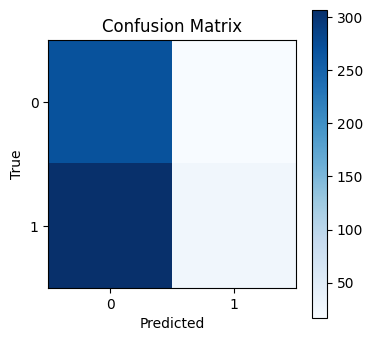

In [274]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### __ROC-AUC__

ROC AUC: 0.5285373309325405


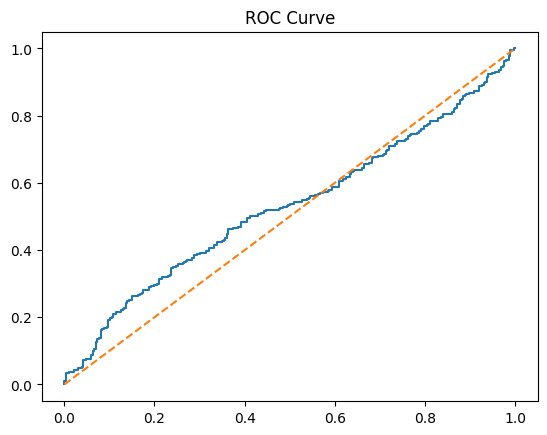

In [275]:
auc = roc_auc_score(y_true, probs[:, 1])
print("ROC AUC:", auc)

fpr, tpr, _ = roc_curve(y_true, probs[:,1])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()


#### __Precision/Recall/F1__

In [276]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.94      0.62       286
           1       0.61      0.08      0.14       334

    accuracy                           0.48       620
   macro avg       0.54      0.51      0.38       620
weighted avg       0.55      0.48      0.36       620

